# Delivery Network Dashboard — 2025

**Audience:** logistics operations managers and fleet leads overseeing multi-city delivery performance.

**Scope:** daily delivery records across 5 hubs (Riyadh, Jeddah, Dammam, Makkah, Madinah) and 3 vehicle classes (Motorbike, Van, Truck), Jan 1 – Dec 31, 2025.

Run all cells top to bottom (`Cell -> Run All`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.facecolor'] = '#0E1420'
plt.rcParams['axes.facecolor'] = '#161D2C'
plt.rcParams['savefig.facecolor'] = '#0E1420'
plt.rcParams['text.color'] = '#F5F3EE'
plt.rcParams['axes.labelcolor'] = '#8792A6'
plt.rcParams['xtick.color'] = '#8792A6'
plt.rcParams['ytick.color'] = '#8792A6'
plt.rcParams['axes.edgecolor'] = '#293347'
plt.rcParams['grid.color'] = '#293347'
plt.rcParams['font.size'] = 11

AMBER = '#F2A31C'
BLUE = '#5E8BFF'
GREEN = '#2FBF8F'
RED = '#E8574C'

HUB_COLORS = {
    'Riyadh-Hub': '#F2A31C',
    'Jeddah-Hub': '#5E8BFF',
    'Makkah-Hub': '#E8574C',
    'Madinah-Hub': '#2FBF8F',
    'Dammam-Hub': '#B98BF2',
}

df = pd.read_csv('logistics_delivery.csv')
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%b')
df['month_num'] = df['date'].dt.month
df.head()

,date,hub,vehicle_type,deliveries_count,on_time_pct,avg_delivery_time_min,fuel_cost_sar,customer_rating,month,month_num
0,2025-01-01,Riyadh-Hub,Motorbike,766,93.2,19.0,1652.95,4.45,Jan,1
1,2025-01-01,Riyadh-Hub,Van,467,93.2,21.1,1889.37,4.35,Jan,1
2,2025-01-01,Riyadh-Hub,Truck,124,93.2,40.5,951.07,4.50,Jan,1
3,2025-01-01,Jeddah-Hub,Motorbike,630,88.0,23.9,1303.48,4.27,Jan,1
4,2025-01-01,Jeddah-Hub,Van,351,88.0,30.6,1485.68,4.05,Jan,1


## 1. Key performance indicators

In [2]:
def wavg(g, val, w):
    return (g[val] * g[w]).sum() / g[w].sum()

total_deliveries = int(df['deliveries_count'].sum())
overall_on_time = wavg(df, 'on_time_pct', 'deliveries_count')
overall_rating = wavg(df, 'customer_rating', 'deliveries_count')
overall_avg_time = wavg(df, 'avg_delivery_time_min', 'deliveries_count')
total_fuel = df['fuel_cost_sar'].sum()

kpis = pd.DataFrame({
    'Metric': ['Total deliveries', 'On-time rate', 'Customer rating', 'Avg delivery time (min)', 'Fuel spend (SAR)'],
    'Value': [f'{total_deliveries:,}', f'{overall_on_time:.1f}%', f'{overall_rating:.2f} / 5',
              f'{overall_avg_time:.1f}', f'{total_fuel:,.0f}']
})
kpis

,Metric,Value
0,Total deliveries,"1,596,724"
1,On-time rate,88.9%
2,Customer rating,4.07 / 5
3,Avg delivery time (min),32.0
4,Fuel spend (SAR),"5,874,312"


## 2. Monthly trend — deliveries vs on-time rate

Bar chart for volume (large, additive) paired with a line for the on-time percentage (bounded 0-100%, a rate). Two different chart types on twin axes make the volume/quality relationship visible in one view — useful for spotting months where growth in deliveries coincided with a drop in service quality (e.g. May–June).

/tmp/ipykernel_1080/4134980075.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly = df.groupby(['month_num', 'month']).apply(


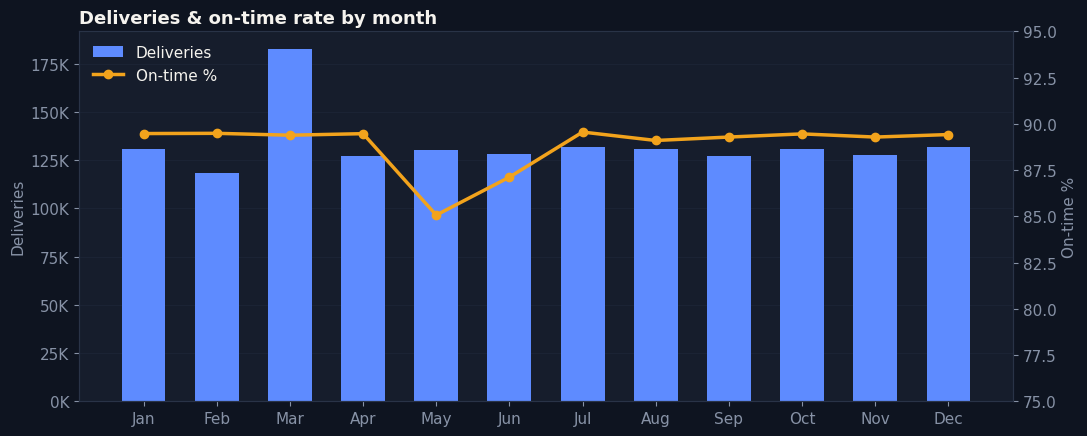

In [3]:
monthly = df.groupby(['month_num', 'month']).apply(
    lambda g: pd.Series({
        'deliveries': g['deliveries_count'].sum(),
        'on_time': wavg(g, 'on_time_pct', 'deliveries_count'),
        'fuel': g['fuel_cost_sar'].sum(),
        'rating': wavg(g, 'customer_rating', 'deliveries_count'),
    })
).reset_index().sort_values('month_num')

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(monthly['month'], monthly['deliveries'], color=BLUE, width=0.6, label='Deliveries', zorder=2)
ax1.set_ylabel('Deliveries')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.grid(axis='y', alpha=0.3)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['on_time'], color=AMBER, marker='o', linewidth=2.5, label='On-time %')
ax2.set_ylabel('On-time %')
ax2.set_ylim(75, 95)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False)
plt.title('Deliveries & on-time rate by month', loc='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Monthly deliveries by hub

A stacked bar chart — the data is categorical (5 hubs) tracked over time, so stacked bars show both each hub's month-to-month volume and its share of the network total in one image, which a line chart would clutter with 5 crossing series.

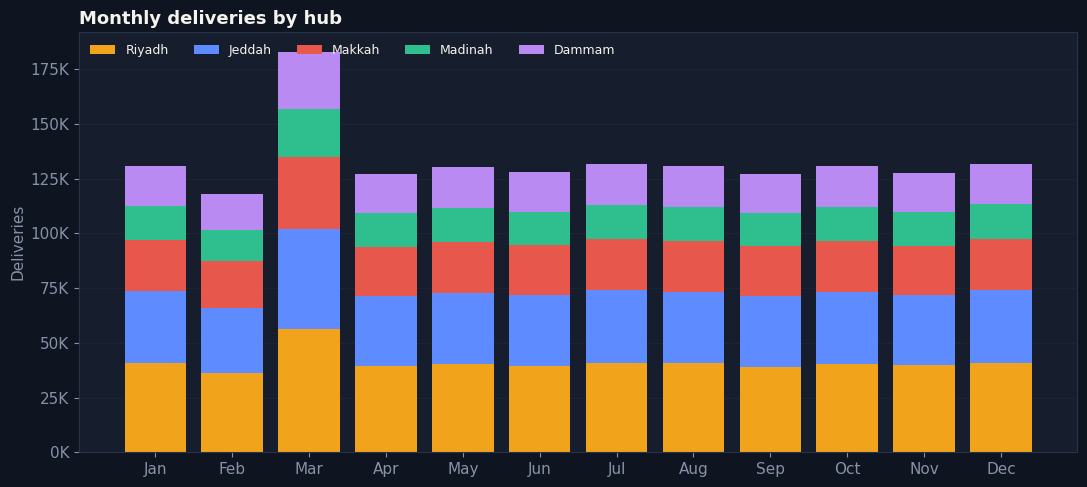

In [4]:
pivot = df.groupby(['month_num', 'month', 'hub'])['deliveries_count'].sum().unstack('hub').reset_index().sort_values('month_num')
hubs_order = list(HUB_COLORS.keys())

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(pivot))
for hub in hubs_order:
    ax.bar(pivot['month'], pivot[hub], bottom=bottom, label=hub.replace('-Hub', ''), color=HUB_COLORS[hub])
    bottom += pivot[hub].values

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_ylabel('Deliveries')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc='upper left', ncol=5, frameon=False, fontsize=9)
plt.title('Monthly deliveries by hub', loc='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Filter to a single hub
Change `HUB_FILTER` below and re-run the cell to inspect one hub's monthly pattern on its own.

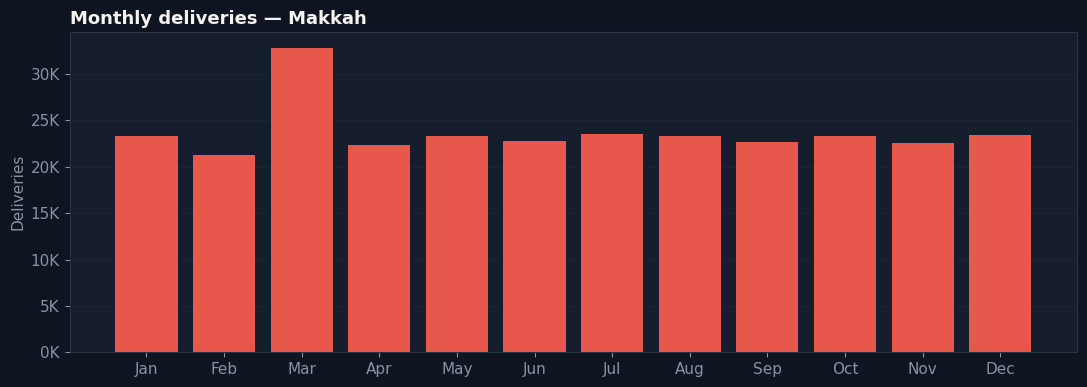

In [5]:
HUB_FILTER = 'Makkah-Hub'  # change to any hub name, or None for all

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(pivot['month'], pivot[HUB_FILTER], color=HUB_COLORS[HUB_FILTER])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_ylabel('Deliveries')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.title(f"Monthly deliveries — {HUB_FILTER.replace('-Hub', '')}", loc='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Vehicle class breakdown

Horizontal bars sized by share of total volume — with only 3 categories and a simple 'which is biggest' comparison, a plain bar is clearer than a pie chart, and horizontal bars leave room for the vehicle name and average time as labels.

/tmp/ipykernel_1080/2563699403.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  veh = df.groupby('vehicle_type').apply(


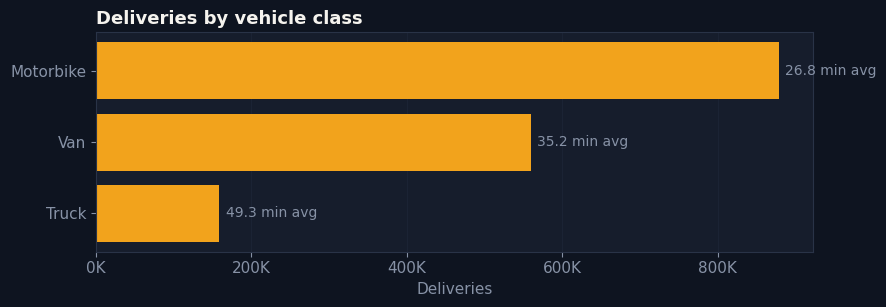

,vehicle_type,deliveries,avg_time,fuel,rating
0,Motorbike,878127.0,26.789303,2012930.85,4.068134
1,Van,559569.0,35.239421,2564334.18,4.066818
2,Truck,159028.0,49.251248,1297046.82,4.088290


In [6]:
veh = df.groupby('vehicle_type').apply(
    lambda g: pd.Series({
        'deliveries': g['deliveries_count'].sum(),
        'avg_time': wavg(g, 'avg_delivery_time_min', 'deliveries_count'),
        'fuel': g['fuel_cost_sar'].sum(),
        'rating': wavg(g, 'customer_rating', 'deliveries_count'),
    })
).reset_index().sort_values('deliveries', ascending=True)

fig, ax = plt.subplots(figsize=(9, 3.2))
bars = ax.barh(veh['vehicle_type'], veh['deliveries'], color=AMBER)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_xlabel('Deliveries')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
for bar, (_, row) in zip(bars, veh.iterrows()):
    ax.text(bar.get_width() + 8000, bar.get_y() + bar.get_height()/2,
            f"{row['avg_time']:.1f} min avg", va='center', color='#8792A6', fontsize=10)
plt.title('Deliveries by vehicle class', loc='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

veh.sort_values('deliveries', ascending=False).reset_index(drop=True)

## 5. Hub performance table

A table rather than a chart — comparing 5 hubs across 5 different metrics at once needs exact values side by side, which a chart would only approximate. Sort by any column by changing `SORT_BY`.

In [7]:
hub_summary = df.groupby('hub').apply(
    lambda g: pd.Series({
        'deliveries': int(g['deliveries_count'].sum()),
        'on_time_pct': round(wavg(g, 'on_time_pct', 'deliveries_count'), 1),
        'avg_time_min': round(wavg(g, 'avg_delivery_time_min', 'deliveries_count'), 1),
        'fuel_sar': round(g['fuel_cost_sar'].sum(), 0),
        'rating': round(wavg(g, 'customer_rating', 'deliveries_count'), 2),
    })
).reset_index()

SORT_BY = 'on_time_pct'  # try: 'deliveries', 'on_time_pct', 'avg_time_min', 'fuel_sar', 'rating'

def highlight_on_time(val):
    if isinstance(val, float) and val < 85:
        return 'color: #E8574C; font-weight: bold'
    return ''

hub_summary.sort_values(SORT_BY, ascending=False).reset_index(drop=True).style.map(
    highlight_on_time, subset=['on_time_pct']
)

/tmp/ipykernel_1080/3298807428.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hub_summary = df.groupby('hub').apply(


,hub,deliveries,on_time_pct,avg_time_min,fuel_sar,rating
0,Dammam-Hub,226595.000000,93.000000,30.800000,833770.000000,4.160000
1,Riyadh-Hub,493389.000000,91.000000,31.500000,1815499.000000,4.110000
2,Madinah-Hub,189942.000000,89.800000,31.400000,698405.000000,4.090000
3,Jeddah-Hub,402055.000000,88.200000,32.200000,1479761.000000,4.060000
4,Makkah-Hub,284743.000000,82.100000,33.900000,1046877.000000,3.930000


## 6. Takeaways

- **Riyadh-Hub** carries the largest share of network volume.
- **Makkah-Hub** has the lowest on-time rate (~82%) and lowest customer rating — the clearest candidate for operational review.
- **Dammam-Hub** leads on both on-time rate and rating despite lower volume.
- **Motorbikes** handle the most deliveries with the fastest average time; **trucks** are slowest but move the highest per-drop weight.
- May–June show a dip in on-time performance worth cross-checking against staffing or demand spikes.